# Loan Approval Prediction - Live Demo
**COEN 330 - Applied Machine Learning**

This notebook loads the final trained pipeline and estimates whether a new application resembles **historically approved** or **historically rejected** applications. Based on that, it makes prediction if the new applicant's loan is going to be approved or rejected.

This demo also runs the **same applicant profiles** through two trained Gradient Boosting pipelines:

1. A model trained **with** `previous_loan_defaults_on_file`.
2. A model trained **without** `previous_loan_defaults_on_file`.

The comparison shows whether removing the previous-default feature changes the estimated approval probability or the final approval/rejection prediction.

## Step 1 - Load the trained pipeline

Required files:

- `models/GradientBoosting.pkl`
- `models/GradientBoosting_WITHOUT_prevdef.pkl`

Both files contain the complete fitted pipeline, including preprocessing and the classifier.


In [36]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


MODEL_FILES = {
    "with_prevdef": "GradientBoosting.pkl",
    "without_prevdef": "GradientBoosting_WITHOUT_prevdef.pkl",
}


def find_project_root(start: Path | None = None) -> Path:
    """Find the project root regardless of where Jupyter was launched."""
    start = (start or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        models_dir = candidate / "models"
        src_dir = candidate / "src"

        models_exist = all(
            (models_dir / filename).exists()
            for filename in MODEL_FILES.values()
        )

        if models_exist and src_dir.exists():
            return candidate

    expected_files = "\n".join(
        f"  models/{filename}"
        for filename in MODEL_FILES.values()
    )

    raise FileNotFoundError(
        "Could not find the project root or both trained models.\n"
        f"Expected:\n{expected_files}\n"
        "and a src/ directory."
    )


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "plots"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# The serialized pipelines reference code from src/preprocessing.py.
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import preprocessing

pipeline_with_prevdef = joblib.load(
    MODELS_DIR / MODEL_FILES["with_prevdef"]
)

pipeline_without_prevdef = joblib.load(
    MODELS_DIR / MODEL_FILES["without_prevdef"]
)

print(f"Project root: {PROJECT_ROOT}")
print("\nLoaded models:")
print(f"  With previous-default feature   : {MODEL_FILES['with_prevdef']}")
print(f"  Without previous-default feature: {MODEL_FILES['without_prevdef']}")
print("\nPipeline steps:")
print(f"  With feature   : {list(pipeline_with_prevdef.named_steps)}")
print(f"  Without feature: {list(pipeline_without_prevdef.named_steps)}")


Project root: D:\Concordia Courses\Summer 2026\COEN 330\COEN 330 Project\COEN330-Machine-Learning-Project

Loaded models:
  With previous-default feature   : GradientBoosting.pkl
  Without previous-default feature: GradientBoosting_WITHOUT_prevdef.pkl

Pipeline steps:
  With feature   : ['pre', 'clf']
  Without feature: ['pre', 'clf']


## Step 2 - Define three applicant profiles

The exact same applicant values are used for both models.  
`loan_percent_income` is calculated automatically so the inputs stay internally consistent.

In [37]:
applicant_a = {
    "person_age": 29,
    "person_gender": "male",
    "person_education": "Bachelor",
    "person_income": 55_000,
    "person_emp_exp": 4,
    "person_home_ownership": "RENT",
    "loan_amnt": 12_000,
    "loan_intent": "EDUCATION",
    "loan_int_rate": 11.5,
    "cb_person_cred_hist_length": 5,
    "credit_score": 640,
    "previous_loan_defaults_on_file": "No",
}

applicant_b = {
    "person_age": 22,
    "person_gender": "female",
    "person_education": "High School",
    "person_income": 18_000,
    "person_emp_exp": 0,
    "person_home_ownership": "RENT",
    "loan_amnt": 14_000,
    "loan_intent": "PERSONAL",
    "loan_int_rate": 18.5,
    "cb_person_cred_hist_length": 2,
    "credit_score": 480,
    "previous_loan_defaults_on_file": "No",
}

applicant_c = {
    "person_age": 27,
    "person_gender": "female",
    "person_education": "Doctorate",
    "person_income": 90_000,
    "person_emp_exp": 8,
    "person_home_ownership": "RENT",
    "loan_amnt": 5_000,
    "loan_intent": "MEDICAL",
    "loan_int_rate": 7.5,
    "cb_person_cred_hist_length": 9,
    "credit_score": 810,
    "previous_loan_defaults_on_file": "Yes",
}


APPLICANTS = {
    "Applicant A": applicant_a,
    "Applicant B": applicant_b,
    "Applicant C": applicant_c,
}


for applicant in APPLICANTS.values():
    applicant["loan_percent_income"] = (
        applicant["loan_amnt"] / applicant["person_income"]
    )


applicant_overview = pd.DataFrame.from_dict(
    APPLICANTS,
    orient="index",
)

display(applicant_overview)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_percent_income
Applicant A,29,male,Bachelor,55000,4,RENT,12000,EDUCATION,11.5,5,640,No,0.218182
Applicant B,22,female,High School,18000,0,RENT,14000,PERSONAL,18.5,2,480,No,0.777778
Applicant C,27,female,Doctorate,90000,8,RENT,5000,MEDICAL,7.5,9,810,Yes,0.055556


## Step 3 - Run each applicant through both models

The reduced model receives all the same applicant information except that the previous-default column is removed before prediction, matching the feature set used during its training.

In [38]:
DEFAULT_THRESHOLD = 0.50
PREV_DEFAULT_COLUMN = "previous_loan_defaults_on_file"


def predict_applicant(
    applicant: dict,
    model_pipeline,
    *,
    uses_prevdef: bool,
    threshold: float = DEFAULT_THRESHOLD,
) -> dict:
    """Predict one applicant using a complete saved pipeline."""
    X_new = pd.DataFrame([applicant])

    if not uses_prevdef:
        X_new = X_new.drop(
            columns=[PREV_DEFAULT_COLUMN],
            errors="ignore",
        )

    if not hasattr(model_pipeline, "predict_proba"):
        raise TypeError(
            "This demo expects the selected model to provide predict_proba()."
        )

    probability = float(
        model_pipeline.predict_proba(X_new)[0, 1]
    )

    decision = (
        "APPROVED"
        if probability >= threshold
        else "REJECTED"
    )

    return {
        "decision": decision,
        "approval_probability": probability,
        "threshold": threshold,
    }


def compare_models(
    applicant: dict,
    profile_name: str,
) -> dict:
    """Run one applicant through both trained pipelines."""
    result_with = predict_applicant(
        applicant,
        pipeline_with_prevdef,
        uses_prevdef=True,
    )

    result_without = predict_applicant(
        applicant,
        pipeline_without_prevdef,
        uses_prevdef=False,
    )

    return {
        "Profile": profile_name,
        "Previous defaults": applicant[PREV_DEFAULT_COLUMN],
        "With feature P(Approved)": result_with["approval_probability"],
        "With feature Decision": result_with["decision"],
        "Without feature P(Approved)": result_without["approval_probability"],
        "Without feature Decision": result_without["decision"],
        "Probability difference (with - without)": (
            result_with["approval_probability"]
            - result_without["approval_probability"]
        ),
        "Decision changed?": (
            result_with["decision"]
            != result_without["decision"]
        ),
    }


comparison = pd.DataFrame([
    compare_models(applicant, profile_name)
    for profile_name, applicant in APPLICANTS.items()
])

display(
    comparison.style.format({
        "With feature P(Approved)": "{:.1%}",
        "Without feature P(Approved)": "{:.1%}",
        "Probability difference (with - without)": "{:+.1%}",
    })
)

comparison_path = RESULTS_DIR / "demo_model_feature_comparison.csv"
comparison.to_csv(comparison_path, index=False)

print(f"Saved comparison table: {comparison_path}")


,Profile,Previous defaults,With feature P(Approved),With feature Decision,Without feature P(Approved),Without feature Decision,Probability difference (with - without),Decision changed?
0,Applicant A,No,20.4%,REJECTED,11.3%,REJECTED,+9.1%,False
1,Applicant B,No,100.0%,APPROVED,99.9%,APPROVED,+0.1%,False
2,Applicant C,Yes,0.0%,REJECTED,9.4%,REJECTED,-9.4%,False


Saved comparison table: D:\Concordia Courses\Summer 2026\COEN 330\COEN 330 Project\COEN330-Machine-Learning-Project\results\demo_model_feature_comparison.csv


## Step 4 - Visual Comparison


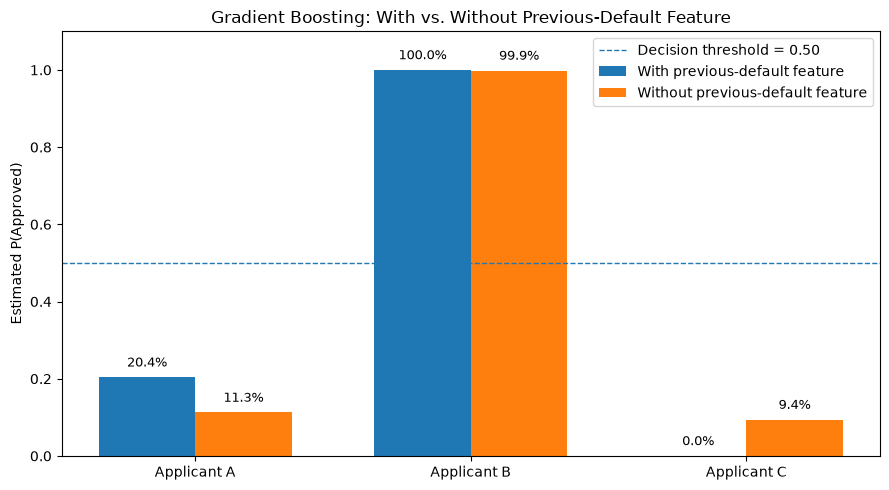

Saved plot: D:\Concordia Courses\Summer 2026\COEN 330\COEN 330 Project\COEN330-Machine-Learning-Project\results\plots\demo_with_vs_without_previous_defaults.png


In [39]:
profiles = comparison["Profile"].tolist()

with_probabilities = comparison[
    "With feature P(Approved)"
].to_numpy()

without_probabilities = comparison[
    "Without feature P(Approved)"
].to_numpy()

x = np.arange(len(profiles))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars_with = ax.bar(
    x - width / 2,
    with_probabilities,
    width,
    label="With previous-default feature",
)

bars_without = ax.bar(
    x + width / 2,
    without_probabilities,
    width,
    label="Without previous-default feature",
)

ax.axhline(
    DEFAULT_THRESHOLD,
    linestyle="--",
    linewidth=1,
    label=f"Decision threshold = {DEFAULT_THRESHOLD:.2f}",
)

for bars in (bars_with, bars_without):
    for bar in bars:
        probability = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            probability + 0.02,
            f"{probability:.1%}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.set_xticks(x)
ax.set_xticklabels(profiles)
ax.set_ylim(0, 1.10)
ax.set_ylabel("Estimated P(Approved)")
ax.set_title(
    "Gradient Boosting: With vs. Without Previous-Default Feature"
)
ax.legend()

plt.tight_layout()

plot_path = (
    PLOTS_DIR
    / "demo_with_vs_without_previous_defaults.png"
)

plt.savefig(
    plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved plot: {plot_path}")


### Interpretation

The previous-loan-default feature affected the models’ estimated approval probabilities, but it did not change the final approval or rejection decision for any of the three applicants at the 0.50 threshold. Applicant A’s approval probability increased from 11.3% to 20.4% when the feature was included, while Applicant C’s probability decreased from 9.4% to 0.0%. Applicant B remained almost unchanged at approximately 100%. This suggests that previous-default history can influence the model’s confidence, even when the final classification remains the same.


## Step 5 - Counterfactual previous-default test

For each applicant, every value is held constant while only  
`previous_loan_defaults_on_file` is changed from `"No"` to `"Yes"`.

Expected behavior:

- The model trained **with** the feature may change its probability or decision.
- The model trained **without** the feature should remain unchanged because that field is removed before prediction.


In [40]:
def previous_default_counterfactual(
    applicant: dict,
    profile_name: str,
) -> dict:
    """Toggle only previous-default history and compare both models."""
    applicant_no = applicant.copy()
    applicant_no[PREV_DEFAULT_COLUMN] = "No"

    applicant_yes = applicant.copy()
    applicant_yes[PREV_DEFAULT_COLUMN] = "Yes"

    with_no = predict_applicant(
        applicant_no,
        pipeline_with_prevdef,
        uses_prevdef=True,
    )

    with_yes = predict_applicant(
        applicant_yes,
        pipeline_with_prevdef,
        uses_prevdef=True,
    )

    without_no = predict_applicant(
        applicant_no,
        pipeline_without_prevdef,
        uses_prevdef=False,
    )

    without_yes = predict_applicant(
        applicant_yes,
        pipeline_without_prevdef,
        uses_prevdef=False,
    )

    return {
        "Profile": profile_name,
        "With feature P(No defaults)": with_no["approval_probability"],
        "With feature P(Yes defaults)": with_yes["approval_probability"],
        "With feature delta (Yes - No)": (
            with_yes["approval_probability"]
            - with_no["approval_probability"]
        ),
        "With feature Decision (No -> Yes)": (
            f"{with_no['decision']} -> {with_yes['decision']}"
        ),
        "With feature decision flipped?": (
            with_no["decision"] != with_yes["decision"]
        ),
        "Without feature P(No defaults)": without_no[
            "approval_probability"
        ],
        "Without feature P(Yes defaults)": without_yes[
            "approval_probability"
        ],
        "Without feature delta (Yes - No)": (
            without_yes["approval_probability"]
            - without_no["approval_probability"]
        ),
        "Without feature Decision (No -> Yes)": (
            f"{without_no['decision']} -> {without_yes['decision']}"
        ),
    }


counterfactual_comparison = pd.DataFrame([
    previous_default_counterfactual(
        applicant,
        profile_name,
    )
    for profile_name, applicant in APPLICANTS.items()
])

display(
    counterfactual_comparison.style.format({
        "With feature P(No defaults)": "{:.1%}",
        "With feature P(Yes defaults)": "{:.1%}",
        "With feature delta (Yes - No)": "{:+.1%}",
        "Without feature P(No defaults)": "{:.1%}",
        "Without feature P(Yes defaults)": "{:.1%}",
        "Without feature delta (Yes - No)": "{:+.1%}",
    })
)

counterfactual_path = (
    RESULTS_DIR
    / "demo_previous_default_counterfactual.csv"
)

counterfactual_comparison.to_csv(
    counterfactual_path,
    index=False,
)

print(f"Saved counterfactual table: {counterfactual_path}")


,Profile,With feature P(No defaults),With feature P(Yes defaults),With feature delta (Yes - No),With feature Decision (No -> Yes),With feature decision flipped?,Without feature P(No defaults),Without feature P(Yes defaults),Without feature delta (Yes - No),Without feature Decision (No -> Yes)
0,Applicant A,20.4%,0.0%,-20.4%,REJECTED -> REJECTED,False,11.3%,11.3%,+0.0%,REJECTED -> REJECTED
1,Applicant B,100.0%,0.1%,-99.9%,APPROVED -> REJECTED,True,99.9%,99.9%,+0.0%,APPROVED -> APPROVED
2,Applicant C,36.1%,0.0%,-36.1%,REJECTED -> REJECTED,False,9.4%,9.4%,+0.0%,REJECTED -> REJECTED


Saved counterfactual table: D:\Concordia Courses\Summer 2026\COEN 330\COEN 330 Project\COEN330-Machine-Learning-Project\results\demo_previous_default_counterfactual.csv


### Counterfactual Interpretation

When only the previous-default value was changed from **No** to **Yes**, the model using this feature sharply reduced the approval probability for all three applicants. The strongest effect occurred for Applicant B, whose prediction changed from **Approved** at 100.0% to **Rejected** at 0.1%. Applicants A and C remained rejected, but their approval probabilities also dropped to nearly zero. In contrast, the model trained without the feature produced identical probabilities and decisions in both scenarios, confirming that it does not rely on previous-default history. These results show strong model sensitivity to the feature, although they indicate association rather than causation.


## Presentation takeaway

We evaluated the same applicants using two Gradient Boosting pipelines. The first model included previous-loan-default history, while the second excluded it. We compared approval probabilities and decisions, then performed a counterfactual test in which only the previous-default value was changed. The reduced model remained unchanged by design, while movement in the full model indicates that it learned an association between previous-default history and historical loan approvals.
